In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

In [ ]:
# loading dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Train shape:", x_train.shape, " Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1246s 7us/step
Train shape: (50000, 32, 32, 3)  Test shape: (10000, 32, 32, 3)


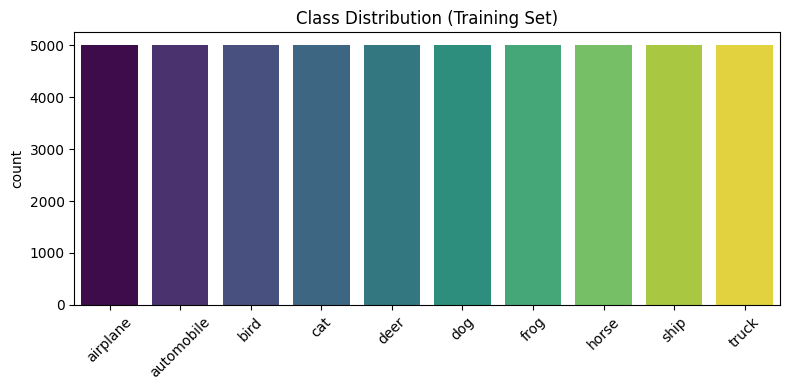

In [ ]:
# class distribution
plt.figure(figsize=(8, 4))
sns.countplot(x=y_train.flatten(), hue = y_train.flatten(), palette='viridis', legend = False)
plt.xticks(range(10), class_names, rotation=45)
plt.title("Class Distribution (Training Set)")
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

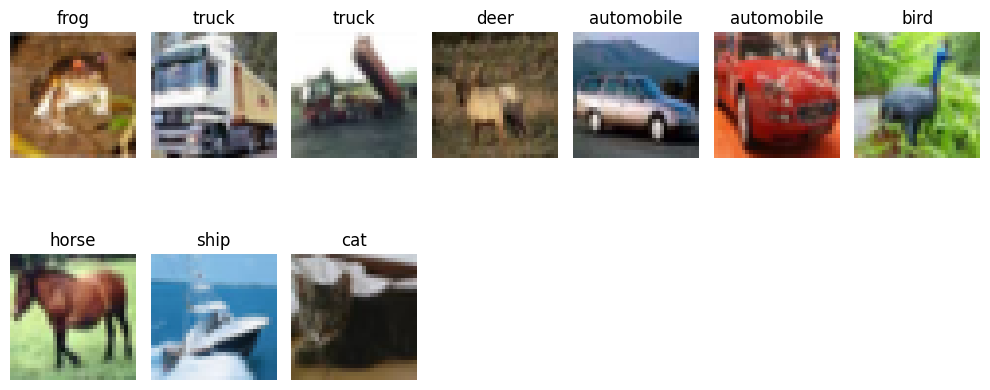

In [ ]:
# Sample images
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 7, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.savefig("sample_images.png")
plt.show()

In [ ]:
# preprocessing

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [ ]:
# convolution -> activation -> max pooling blocks -> flatten -> dense
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu'),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,986 (1.54 MB)

 Trainable params: 402,986 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# training

history = model.fit(x_train, y_train_cat,
                    validation_data=(x_test, y_test_cat),
                    epochs=100,
                    batch_size=64,
                    verbose=2)

Epoch 1/100
782/782 - 6s - 8ms/step - accuracy: 0.8448 - loss: 0.4493 - val_accuracy: 0.8224 - val_loss: 0.5529
Epoch 2/100
782/782 - 6s - 7ms/step - accuracy: 0.8467 - loss: 0.4412 - val_accuracy: 0.8242 - val_loss: 0.5463
Epoch 3/100
782/782 - 6s - 7ms/step - accuracy: 0.8447 - loss: 0.4461 - val_accuracy: 0.8242 - val_loss: 0.5437
Epoch 4/100
782/782 - 6s - 8ms/step - accuracy: 0.8459 - loss: 0.4442 - val_accuracy: 0.8227 - val_loss: 0.5513
Epoch 5/100
782/782 - 6s - 7ms/step - accuracy: 0.8459 - loss: 0.4402 - val_accuracy: 0.8198 - val_loss: 0.5590
Epoch 6/100
782/782 - 6s - 8ms/step - accuracy: 0.8478 - loss: 0.4414 - val_accuracy: 0.8314 - val_loss: 0.5365
Epoch 7/100
782/782 - 6s - 7ms/step - accuracy: 0.8503 - loss: 0.4355 - val_accuracy: 0.8151 - val_loss: 0.5747
Epoch 8/100
782/782 - 6s - 7ms/step - accuracy: 0.8489 - loss: 0.4386 - val_accuracy: 0.8255 - val_loss: 0.5384
Epoch 9/100
782/782 - 6s - 7ms/step - accuracy: 0.8487 - loss: 0.4380 - val_accuracy: 0.8252 - val_loss:

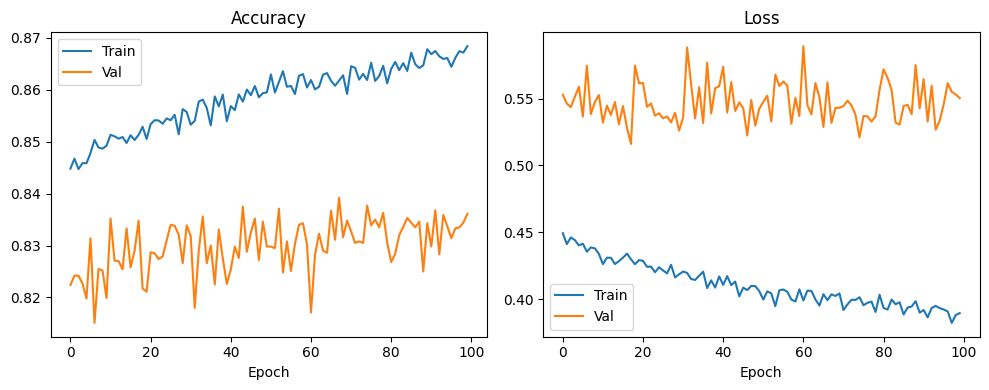

In [ ]:
# accuracy/loss curves

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy"); plt.xlabel("Epoch"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss"); plt.xlabel("Epoch"); plt.legend()
plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

In [ ]:
# evaluation metrics

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = y_test.flatten()

print("\nTest Accuracy :", accuracy_score(y_true, y_pred))
print("Precision (macro):", precision_score(y_true, y_pred, average='macro'))
print("Recall (macro)   :", recall_score(y_true, y_pred, average='macro'))
print("F1-score (macro) :", f1_score(y_true, y_pred, average='macro'))

print("\nClassification Report:\n",
      classification_report(y_true, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Test Accuracy : 0.8361
Precision (macro): 0.8384534334507405
Recall (macro)   : 0.8360999999999998
F1-score (macro) : 0.8362122107005756

Classification Report:
               precision    recall  f1-score   support

    airplane       0.86      0.82      0.84      1000
  automobile       0.93      0.91      0.92      1000
        bird       0.77      0.78      0.77      1000
         cat       0.68      0.72      0.70      1000
        deer       0.86      0.80      0.83      1000
         dog       0.78      0.76      0.77      1000
        frog       0.82      0.91      0.86      1000
       horse       0.93      0.81      0.87      1000
        ship       0.90      0.92      0.91      1000
       truck       0.85      0.93      0.89      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



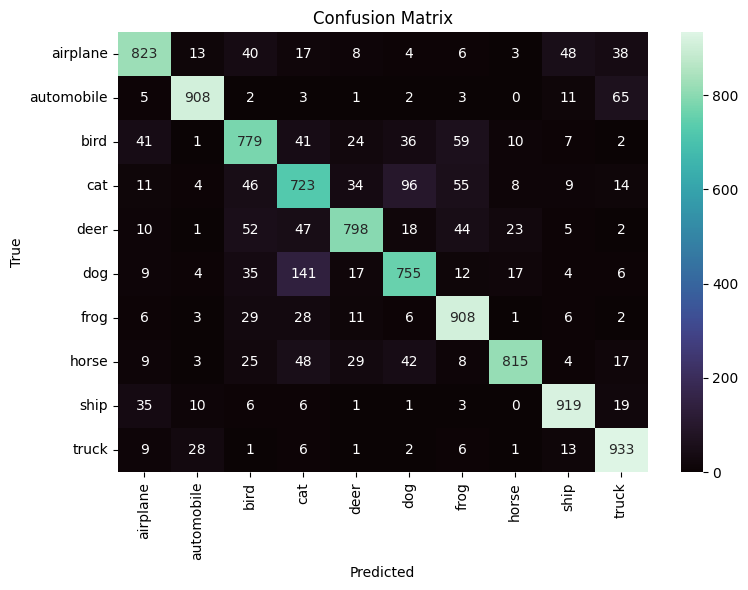

In [ ]:
# confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='mako',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step


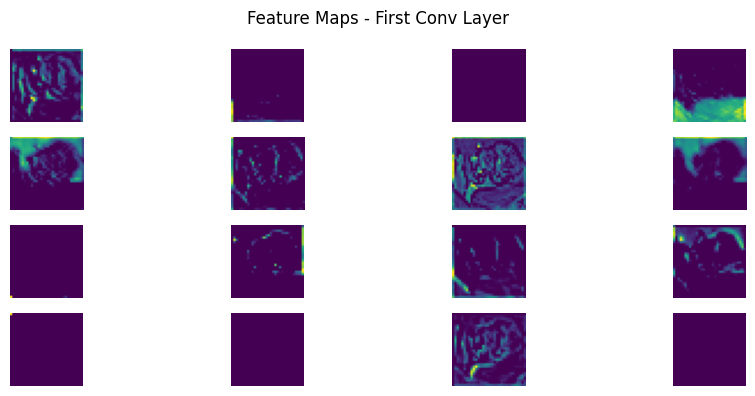


Done. Saved: class_distribution.png, sample_images.png, training_curves.png, confusion_matrix.png, feature_maps.png


In [ ]:
# feature map
conv_layers = [l.output for l in model.layers if isinstance(l, layers.Conv2D)]
activation_model = models.Model(inputs=model.inputs, outputs=conv_layers)

sample = x_test[0:1]
activations = activation_model.predict(sample)

first_layer_act = activations[0]
plt.figure(figsize=(10, 4))
for i in range(min(16, first_layer_act.shape[-1])):
    plt.subplot(4, 4, i + 1)
    plt.imshow(first_layer_act[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.suptitle("Feature Maps - First Conv Layer")
plt.tight_layout()
plt.savefig("feature_maps.png")
plt.show()

print("\nDone. Saved: class_distribution.png, sample_images.png, "
      "training_curves.png, confusion_matrix.png, feature_maps.png")

In [ ]:
# average pooling

model_avg = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu'),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.AveragePooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.AveragePooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.AveragePooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_avg.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_avg = model_avg.fit(x_train, y_train_cat,
                            validation_data=(x_test, y_test_cat),
                            epochs=100,
                            batch_size=64,
                            verbose=2)

Epoch 1/100
782/782 - 27s - 35ms/step - accuracy: 0.3570 - loss: 1.7443 - val_accuracy: 0.5071 - val_loss: 1.3478
Epoch 2/100
782/782 - 5s - 6ms/step - accuracy: 0.5108 - loss: 1.3650 - val_accuracy: 0.5877 - val_loss: 1.1516
Epoch 3/100
782/782 - 6s - 7ms/step - accuracy: 0.5744 - loss: 1.1946 - val_accuracy: 0.6368 - val_loss: 1.0269
Epoch 4/100
782/782 - 5s - 6ms/step - accuracy: 0.6181 - loss: 1.0824 - val_accuracy: 0.6742 - val_loss: 0.9192
Epoch 5/100
782/782 - 5s - 6ms/step - accuracy: 0.6494 - loss: 0.9925 - val_accuracy: 0.7067 - val_loss: 0.8265
Epoch 6/100
782/782 - 5s - 7ms/step - accuracy: 0.6725 - loss: 0.9310 - val_accuracy: 0.7259 - val_loss: 0.7835
Epoch 7/100
782/782 - 5s - 6ms/step - accuracy: 0.6960 - loss: 0.8751 - val_accuracy: 0.7317 - val_loss: 0.7666
Epoch 8/100
782/782 - 5s - 7ms/step - accuracy: 0.7096 - loss: 0.8334 - val_accuracy: 0.7424 - val_loss: 0.7453
Epoch 9/100
782/782 - 5s - 6ms/step - accuracy: 0.7230 - loss: 0.7983 - val_accuracy: 0.7591 - val_los

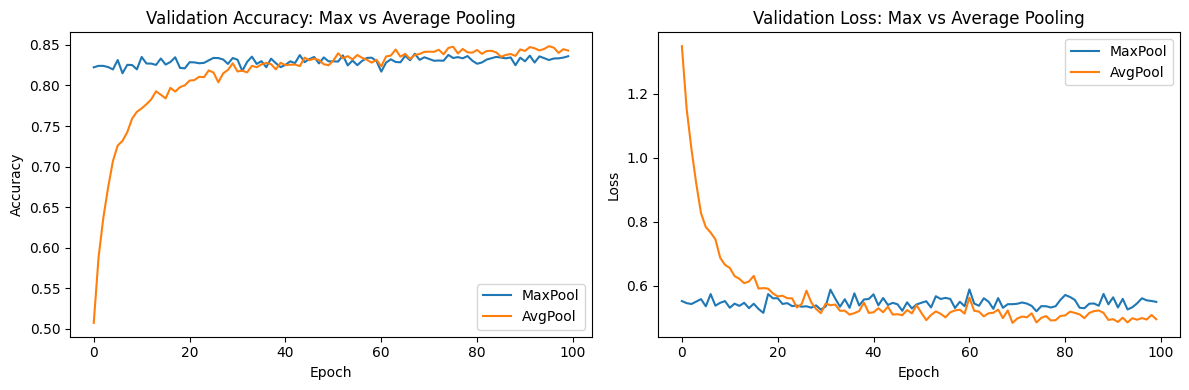

Pooling     Train Acc   Val Acc     Val Loss  
----------------------------------------------
MaxPool     0.8684      0.8361      0.5504    
AvgPool     0.8839      0.8431      0.4963    


In [ ]:
# maxpool and avgpool COMPARISION
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['val_accuracy'], label='MaxPool')
plt.plot(history_avg.history['val_accuracy'], label='AvgPool')
plt.title("Validation Accuracy: Max vs Average Pooling")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['val_loss'], label='MaxPool')
plt.plot(history_avg.history['val_loss'], label='AvgPool')
plt.title("Validation Loss: Max vs Average Pooling")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.tight_layout()
plt.savefig("pooling_comparison.png")
plt.show()

# Side-by-side final numbers
print(f"{'Pooling':<12}{'Train Acc':<12}{'Val Acc':<12}{'Val Loss':<10}")
print("-" * 46)
print(f"{'MaxPool':<12}{history.history['accuracy'][-1]:<12.4f}"
      f"{history.history['val_accuracy'][-1]:<12.4f}"
      f"{history.history['val_loss'][-1]:<10.4f}")
print(f"{'AvgPool':<12}{history_avg.history['accuracy'][-1]:<12.4f}"
      f"{history_avg.history['val_accuracy'][-1]:<12.4f}"
      f"{history_avg.history['val_loss'][-1]:<10.4f}")